<a href="https://colab.research.google.com/github/mfaiz23/Churn-Prediction-OCTE/blob/main/02_smote_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚖️ NOTEBOOK 02 — SMOTE BEFORE SPLIT & FEATURE SELECTION
**Eksperimen 4: SMOTE Before Split + OCTE (Optimal Causal Decision Trees Ensemble)**

---
## Deskripsi
Notebook ini menjalankan dua tahap kritis sebelum pemodelan:

**Bagian A — Balancing dengan SMOTE Before Split:**
Menerapkan SMOTE pada **seluruh dataset** sebelum dilakukan train-test split. Ini adalah desain eksperimen yang sengaja dipilih (Experiment 4) untuk menganalisis dampak metodologis dari urutan SMOTE.

> ⚠️ **Catatan Metodologis:** Pendekatan SMOTE-before-split berpotensi menyebabkan data leakage karena observasi sintetis yang overlap antara train dan test. Ini dipelajari secara sengaja dalam eksperimen ini.

**Bagian B — Feature Selection dengan Information Gain:**
Memilih 15 fitur terbaik menggunakan Mutual Information (Information Gain) untuk mengurangi dimensionalitas sambil mempertahankan fitur paling informatif.

## Prasyarat
> ✅ Notebook 01 harus sudah dijalankan dan file `data_cleaned.csv` tersedia di Google Drive.

---
## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/last_experiment'
print(f'✅ Google Drive mounted. Base path: {BASE_PATH}')

Mounted at /content/drive
✅ Google Drive mounted. Base path: /content/drive/MyDrive/last_experiment


---
## Cell 2 — Install & Import Library

In [ ]:
# Install imbalanced-learn jika belum tersedia
!pip install imbalanced-learn -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

print('✅ Semua library berhasil di-import.')

✅ Semua library berhasil di-import.


---
## Cell 3 — Load Data Hasil Pre-processing
Memuat `data_cleaned.csv` yang dihasilkan oleh Notebook 01.

In [ ]:
PROCESSED_PATH = f'{BASE_PATH}/data/processed/data_cleaned.csv'

if not os.path.exists(PROCESSED_PATH):
    raise FileNotFoundError(
        f'❌ File tidak ditemukan: {PROCESSED_PATH}\n'
        '   Pastikan Notebook 01 sudah dijalankan terlebih dahulu.'
    )

df = pd.read_csv(PROCESSED_PATH)
print(f'📊 Dataset berhasil dimuat.')
print(f'   Dimensi : {df.shape[0]:,} baris x {df.shape[1]} kolom')

# Cek distribusi kelas awal
churn_dist = df['churn value'].value_counts()
imbalance_ratio = churn_dist.max() / churn_dist.min()
print(f'\n🎯 Distribusi Kelas Awal (Imbalanced):')
print(f'   Kelas 0 (Stay)  : {churn_dist.get(0, 0):,} ({churn_dist.get(0, 0)/len(df)*100:.1f}%)')
print(f'   Kelas 1 (Churn) : {churn_dist.get(1, 0):,} ({churn_dist.get(1, 0)/len(df)*100:.1f}%)')
print(f'   Rasio Imbalance : {imbalance_ratio:.2f}:1')

📊 Dataset berhasil dimuat.
   Dimensi : 7,043 baris x 30 kolom

🎯 Distribusi Kelas Awal (Imbalanced):
   Kelas 0 (Stay)  : 5,174 (73.5%)
   Kelas 1 (Churn) : 1,869 (26.5%)
   Rasio Imbalance : 2.77:1


---
## Cell 4 — Pemisahan Fitur dan Target

In [ ]:
TARGET_COL = 'churn value'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Konversi ke float untuk kompatibilitas SMOTE
X = X.astype(float)

print(f'📐 Dimensi Fitur (X) : {X.shape}')
print(f'📐 Dimensi Target (y): {y.shape}')
print(f'🔖 Nama fitur ({X.shape[1]} total):')
print('   ' + ', '.join(X.columns.tolist()))

📐 Dimensi Fitur (X) : (7043, 29)
📐 Dimensi Target (y): (7043,)
🔖 Nama fitur (29 total):
   tenure months, monthly charges, total charges, treatment_w, gender_Male, senior citizen_Yes, partner_Yes, dependents_Yes, phone service_Yes, multiple lines_No phone service, multiple lines_Yes, internet service_Fiber optic, internet service_No, online security_No internet service, online security_Yes, online backup_No internet service, online backup_Yes, device protection_No internet service, device protection_Yes, tech support_No internet service, tech support_Yes, streaming tv_No internet service, streaming tv_Yes, streaming movies_No internet service, streaming movies_Yes, paperless billing_Yes, payment method_Credit card (automatic), payment method_Electronic check, payment method_Mailed check


---
## Cell 5 — Visualisasi Distribusi Kelas Sebelum SMOTE
Menampilkan distribusi kelas awal untuk mendokumentasikan ketidakseimbangan data.

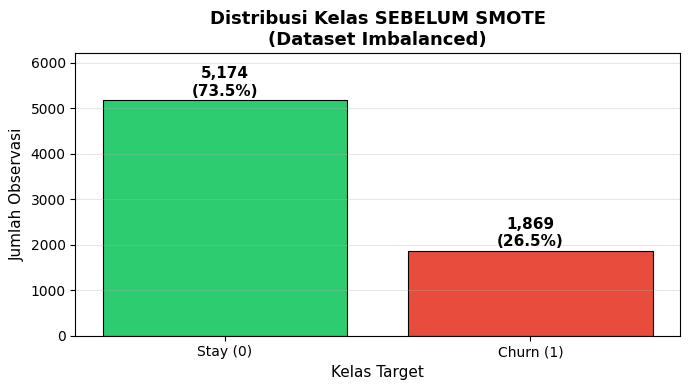

💾 Gambar disimpan ke figures/smote/


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

counts_before = y.value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Stay (0)', 'Churn (1)'], counts_before.values, color=colors, edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, counts_before.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
            f'{count:,}\n({count/len(y)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribusi Kelas SEBELUM SMOTE\n(Dataset Imbalanced)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas Target', fontsize=11)
ax.set_ylabel('Jumlah Observasi', fontsize=11)
ax.set_ylim(0, counts_before.max() * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/figures/smote/distribution_before_smote.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Gambar disimpan ke figures/smote/')

---
## Cell 6 — Penerapan SMOTE (Before Split)
SMOTE (**S**ynthetic **M**inority **O**ver-sampling **TE**chnique) menghasilkan observasi sintetis pada kelas minoritas dengan cara interpolasi di antara tetangga terdekat dalam ruang fitur.

**Desain Eksperimen 4:** SMOTE diterapkan pada **seluruh dataset** sebelum split, bukan hanya pada data training.

In [ ]:
print('🔄 Menerapkan SMOTE pada seluruh dataset (before split)...')
print(f'   Dataset awal  : {X.shape[0]:,} observasi')

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Statistik setelah SMOTE
counts_after = pd.Series(y_resampled).value_counts().sort_index()
n_synthetic = len(X_resampled) - len(X)

print(f'   Dataset setelah SMOTE: {len(X_resampled):,} observasi')
print(f'   Observasi sintetis ditambahkan: {n_synthetic:,}')
print(f'\n🎯 Distribusi Kelas Setelah SMOTE:')
print(f'   Kelas 0 (Stay)  : {counts_after.get(0, 0):,} ({counts_after.get(0, 0)/len(y_resampled)*100:.1f}%)')
print(f'   Kelas 1 (Churn) : {counts_after.get(1, 0):,} ({counts_after.get(1, 0)/len(y_resampled)*100:.1f}%)')
print('✅ SMOTE berhasil diterapkan. Dataset sekarang seimbang.')

🔄 Menerapkan SMOTE pada seluruh dataset (before split)...
   Dataset awal  : 7,043 observasi
   Dataset setelah SMOTE: 10,348 observasi
   Observasi sintetis ditambahkan: 3,305

🎯 Distribusi Kelas Setelah SMOTE:
   Kelas 0 (Stay)  : 5,174 (50.0%)
   Kelas 1 (Churn) : 5,174 (50.0%)
✅ SMOTE berhasil diterapkan. Dataset sekarang seimbang.


---
## Cell 7 — Visualisasi Perbandingan Sebelum & Setelah SMOTE

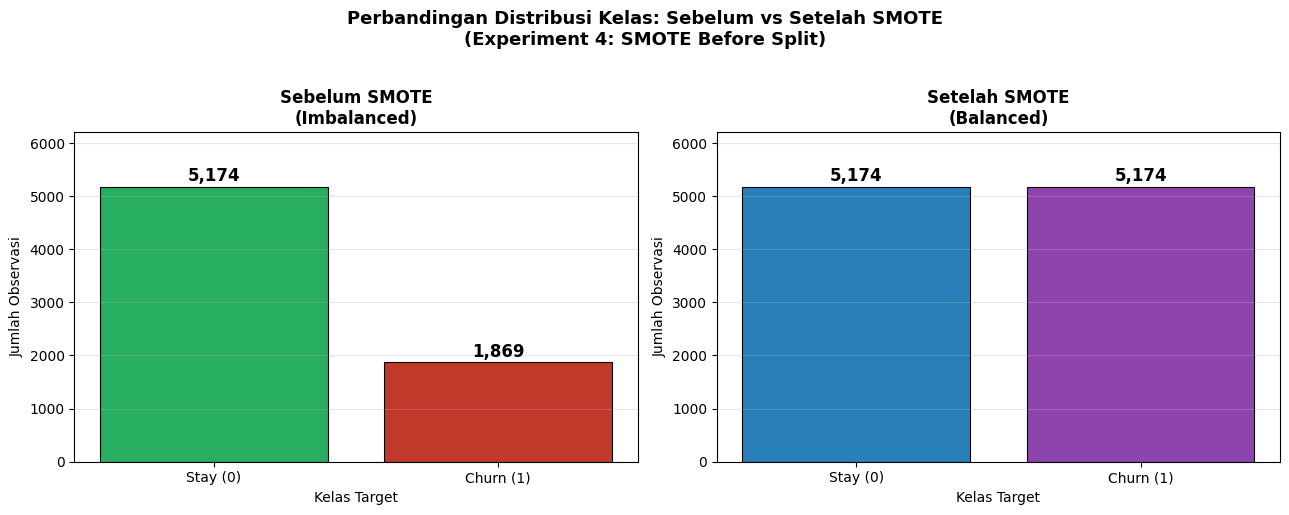

💾 Gambar perbandingan disimpan ke: /content/drive/MyDrive/last_experiment/figures/smote/distribution_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel kiri: Sebelum SMOTE
counts_before = y.value_counts().sort_index()
bars1 = axes[0].bar(['Stay (0)', 'Churn (1)'], counts_before.values,
                    color=['#27ae60', '#c0392b'], edgecolor='black', linewidth=0.8)
for bar, count in zip(bars1, counts_before.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Sebelum SMOTE\n(Imbalanced)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kelas Target'); axes[0].set_ylabel('Jumlah Observasi')
axes[0].set_ylim(0, max(counts_before.values) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Panel kanan: Setelah SMOTE
bars2 = axes[1].bar(['Stay (0)', 'Churn (1)'], counts_after.values,
                    color=['#2980b9', '#8e44ad'], edgecolor='black', linewidth=0.8)
for bar, count in zip(bars2, counts_after.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Setelah SMOTE\n(Balanced)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kelas Target'); axes[1].set_ylabel('Jumlah Observasi')
axes[1].set_ylim(0, max(counts_after.values) * 1.2)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Setelah SMOTE\n(Experiment 4: SMOTE Before Split)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

FIG_PATH = f'{BASE_PATH}/figures/smote/distribution_comparison.png'
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Gambar perbandingan disimpan ke: {FIG_PATH}')

---
## Cell 8 — Stratified Train-Test Split (80:20)
Membagi dataset yang sudah seimbang menjadi data training (80%) dan data testing (20%) dengan stratifikasi untuk mempertahankan proporsi kelas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print('✅ Train-Test Split selesai (80:20 Stratified):')
print(f'   X_train : {X_train.shape}  | y_train : {y_train.shape}')
print(f'   X_test  : {X_test.shape}   | y_test  : {y_test.shape}')

y_train_dist = pd.Series(y_train).value_counts()
y_test_dist  = pd.Series(y_test).value_counts()
print(f'\n📊 Distribusi Kelas di Train Set:')
print(f'   Stay(0): {y_train_dist.get(0,0):,} | Churn(1): {y_train_dist.get(1,0):,}')
print(f'📊 Distribusi Kelas di Test Set:')
print(f'   Stay(0): {y_test_dist.get(0,0):,}  | Churn(1): {y_test_dist.get(1,0):,}')

✅ Train-Test Split selesai (80:20 Stratified):
   X_train : (8278, 29)  | y_train : (8278,)
   X_test  : (2070, 29)   | y_test  : (2070,)

📊 Distribusi Kelas di Train Set:
   Stay(0): 4,139 | Churn(1): 4,139
📊 Distribusi Kelas di Test Set:
   Stay(0): 1,035  | Churn(1): 1,035


---
## Cell 9 — Simpan Data Train/Test ke Google Drive

In [ ]:
# Konversi kembali ke DataFrame jika berupa numpy array
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)
y_train_s  = pd.Series(y_train, name=TARGET_COL)
y_test_s   = pd.Series(y_test,  name=TARGET_COL)

# Simpan
X_train_df.to_csv(f'{BASE_PATH}/data/processed/X_train.csv', index=False)
X_test_df.to_csv( f'{BASE_PATH}/data/processed/X_test.csv',  index=False)
y_train_s.to_csv( f'{BASE_PATH}/data/processed/y_train.csv', index=False, header=True)
y_test_s.to_csv(  f'{BASE_PATH}/data/processed/y_test.csv',  index=False, header=True)

print('💾 Data train/test berhasil disimpan ke Google Drive:')
print(f'   → data/processed/X_train.csv ({X_train_df.shape[0]:,} baris)')
print(f'   → data/processed/X_test.csv  ({X_test_df.shape[0]:,} baris)')
print(f'   → data/processed/y_train.csv')
print(f'   → data/processed/y_test.csv')

💾 Data train/test berhasil disimpan ke Google Drive:
   → data/processed/X_train.csv (8,278 baris)
   → data/processed/X_test.csv  (2,070 baris)
   → data/processed/y_train.csv
   → data/processed/y_test.csv


---
# 🔬 BAGIAN B — FEATURE SELECTION MENGGUNAKAN INFORMATION GAIN

**Information Gain** (juga dikenal sebagai Mutual Information) mengukur seberapa banyak informasi tentang kelas target yang diberikan oleh suatu fitur. Fitur dengan skor IG tinggi memiliki hubungan statistik yang kuat dengan variabel target.

> ⚠️ **Penting:** Variabel `treatment_w` dipisahkan dari proses seleksi fitur dan kemudian ditambahkan kembali karena variabel ini adalah variabel kausal utama yang **tidak boleh dieliminasi**.

---
## Cell 10 — Isolasi Variabel Treatment
Variabel `treatment_w` dipisahkan sebelum Feature Selection untuk memastikan ia **tidak tereliminasi** dalam proses ranking fitur.

In [ ]:
# Load data (sudah tersedia dari cell sebelumnya, tapi reload untuk keamanan)
X_train_fs = X_train_df.copy()
X_test_fs  = X_test_df.copy()
y_train_fs = y_train_s.copy()

# Isolasi variabel treatment
w_train = X_train_fs['treatment_w'].copy()
w_test  = X_test_fs['treatment_w'].copy()

X_train_noW = X_train_fs.drop(columns=['treatment_w'])
X_test_noW  = X_test_fs.drop(columns=['treatment_w'])

print('🔒 Variabel treatment_w berhasil diisolasi.')
print(f'   Fitur untuk seleksi : {X_train_noW.shape[1]} kolom (excluding treatment_w)')
print(f'   W_train shape       : {w_train.shape}')
print(f'   W_test shape        : {w_test.shape}')

🔒 Variabel treatment_w berhasil diisolasi.
   Fitur untuk seleksi : 28 kolom (excluding treatment_w)
   W_train shape       : (8278,)
   W_test shape        : (2070,)


---
## Cell 11 — Perhitungan Skor Information Gain
Menghitung skor Information Gain (Mutual Information) untuk setiap fitur terhadap variabel target.

In [ ]:
print('🧮 Menghitung Information Gain untuk setiap fitur...')
ig_scores = mutual_info_classif(X_train_noW, y_train_fs, random_state=42)

ig_df = pd.DataFrame({
    'Feature': X_train_noW.columns,
    'IG_Score': ig_scores
}).sort_values(by='IG_Score', ascending=False).reset_index(drop=True)

print(f'✅ Information Gain dihitung untuk {len(ig_df)} fitur.')
print(f'\n📊 Top 15 Fitur Berdasarkan Information Gain:')
print(f'{"No.":<5} {"Fitur":<40} {"IG Score":>10}')
print('-' * 57)
for i, row in ig_df.head(15).iterrows():
    print(f'{i+1:<5} {row["Feature"]:<40} {row["IG_Score"]:>10.4f}')

🧮 Menghitung Information Gain untuk setiap fitur...
✅ Information Gain dihitung untuk 28 fitur.

📊 Top 15 Fitur Berdasarkan Information Gain:
No.   Fitur                                      IG Score
---------------------------------------------------------
1     tenure months                                0.2263
2     payment method_Electronic check              0.1521
3     partner_Yes                                  0.1280
4     paperless billing_Yes                        0.1152
5     monthly charges                              0.1146
6     gender_Male                                  0.1130
7     total charges                                0.1105
8     tech support_Yes                             0.1051
9     online backup_Yes                            0.0902
10    internet service_Fiber optic                 0.0892
11    dependents_Yes                               0.0892
12    online security_Yes                          0.0889
13    senior citizen_Yes                      

---
## Cell 12 — Visualisasi Top 15 Fitur (Information Gain)

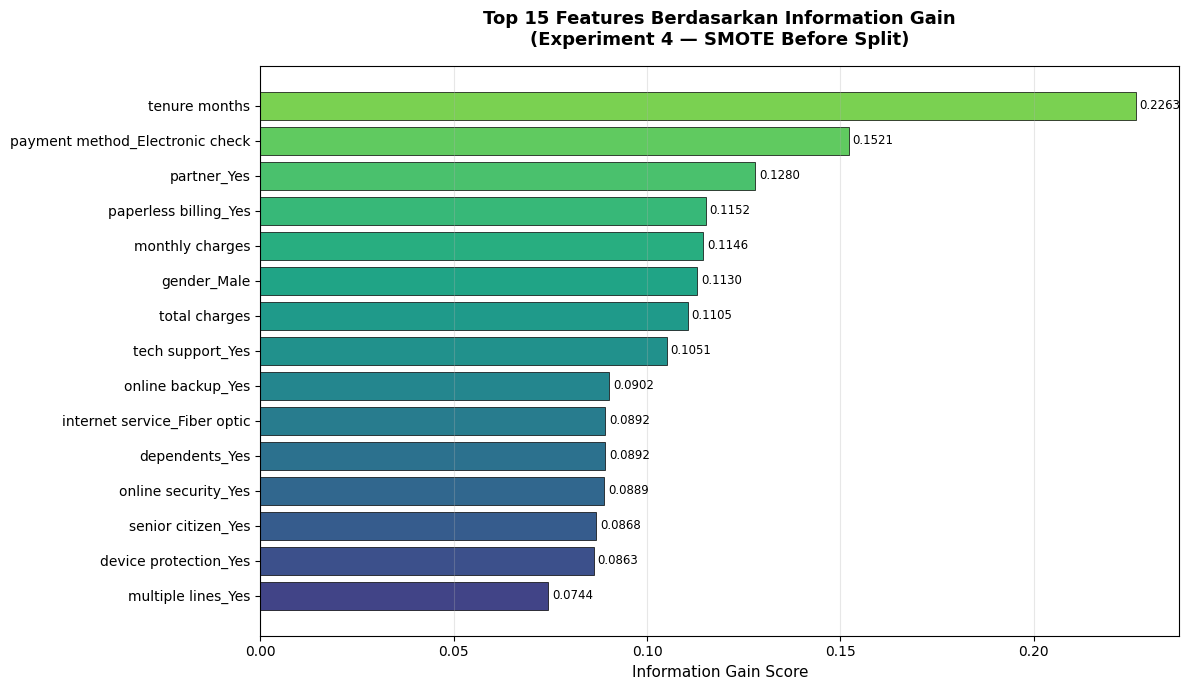

💾 Gambar IG disimpan ke: /content/drive/MyDrive/last_experiment/figures/features/information_gain_scores.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

top15 = ig_df.head(15)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, 15))
bars = ax.barh(range(15), top15['IG_Score'].values[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)

ax.set_yticks(range(15))
ax.set_yticklabels(top15['Feature'].values[::-1], fontsize=10)
ax.set_xlabel('Information Gain Score', fontsize=11)
ax.set_title('Top 15 Features Berdasarkan Information Gain\n(Experiment 4 — SMOTE Before Split)',
             fontsize=13, fontweight='bold', pad=15)

# Tambahkan label nilai di setiap bar
for bar, score in zip(bars, top15['IG_Score'].values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
            f'{score:.4f}', va='center', fontsize=8.5)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

FIG_PATH = f'{BASE_PATH}/figures/features/information_gain_scores.png'
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Gambar IG disimpan ke: {FIG_PATH}')

---
## Cell 13 — Seleksi 15 Fitur Terbaik & Rekonstruksi Dataset

In [ ]:
TOP_N = 15  # @param {type:'integer'}

selected_features = ig_df['Feature'].head(TOP_N).tolist()

# Rekonstruksi dataset dengan fitur terpilih + treatment_w
X_train_selected = X_train_noW[selected_features].copy()
X_test_selected  = X_test_noW[selected_features].copy()

# Tambahkan kembali treatment_w (wajib ada untuk model OCTE)
X_train_selected['treatment_w'] = w_train.values
X_test_selected['treatment_w']  = w_test.values

print(f'✅ Seleksi {TOP_N} fitur terbaik selesai.')
print(f'   Fitur terpilih (+ treatment_w = {X_train_selected.shape[1]} total):')
for i, feat in enumerate(selected_features, 1):
    score = ig_df.loc[ig_df['Feature'] == feat, 'IG_Score'].values[0]
    print(f'   {i:>2}. {feat:<40} (IG: {score:.4f})')
print(f'   \n   + treatment_w (variabel kausal — selalu disertakan)')

✅ Seleksi 15 fitur terbaik selesai.
   Fitur terpilih (+ treatment_w = 16 total):
    1. tenure months                            (IG: 0.2263)
    2. payment method_Electronic check          (IG: 0.1521)
    3. partner_Yes                              (IG: 0.1280)
    4. paperless billing_Yes                    (IG: 0.1152)
    5. monthly charges                          (IG: 0.1146)
    6. gender_Male                              (IG: 0.1130)
    7. total charges                            (IG: 0.1105)
    8. tech support_Yes                         (IG: 0.1051)
    9. online backup_Yes                        (IG: 0.0902)
   10. internet service_Fiber optic             (IG: 0.0892)
   11. dependents_Yes                           (IG: 0.0892)
   12. online security_Yes                      (IG: 0.0889)
   13. senior citizen_Yes                       (IG: 0.0868)
   14. device protection_Yes                    (IG: 0.0863)
   15. multiple lines_Yes                       (IG: 0.0744)
   

---
## Cell 14 — Simpan Hasil Feature Selection ke Google Drive

In [ ]:
# Simpan dataset terseleksi
X_train_selected.to_csv(f'{BASE_PATH}/data/processed/X_train_selected.csv', index=False)
X_test_selected.to_csv( f'{BASE_PATH}/data/processed/X_test_selected.csv',  index=False)

# Simpan ranking Information Gain
ig_df.to_csv(f'{BASE_PATH}/results/metrics/information_gain_ranking.csv', index=False)

print('💾 Semua artefak berhasil disimpan ke Google Drive:')
print(f'   → data/processed/X_train_selected.csv ({X_train_selected.shape})')
print(f'   → data/processed/X_test_selected.csv  ({X_test_selected.shape})')
print(f'   → results/metrics/information_gain_ranking.csv')
print('\n✅ Notebook 02 selesai. Lanjutkan ke Notebook 03: Pemodelan OCTE & Baseline.')

💾 Semua artefak berhasil disimpan ke Google Drive:
   → data/processed/X_train_selected.csv ((8278, 16))
   → data/processed/X_test_selected.csv  ((2070, 16))
   → results/metrics/information_gain_ranking.csv

✅ Notebook 02 selesai. Lanjutkan ke Notebook 03: Pemodelan OCTE & Baseline.
